In [1]:
import numpy as np
import DABI_manipulator.Flir_Convert as FC
import sys
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
import scipy.optimize as opt
import DABI_manipulator.merge_assistant_files as DB
import datetime

In [2]:
# image directory
base_dir = "V:\\"

specimen = "RAD-BD-005"
experiment = "(250818) Creep + Static Experiment"

base_image_dir = os.path.join(base_dir, "Data", "Specimen Directory", "Bonded_DABI", specimen, experiment)

# Merge xlsx files in directory
image_dir = base_image_dir
DB.merge_DABI_data(specimen, experiment, base_dir)

In [3]:
# initial image parameters
camera_parameters = {}
external_optics = {}

# reflected energy
camera_parameters["Emiss"] = 1.0
camera_parameters["distance"] = 0.36
camera_parameters["TRefl"] = 293.14

# atmospheric attenuation
camera_parameters["TAtmC"] = 293.14
camera_parameters["TAtm"] = camera_parameters["TAtmC"] + 273.15
camera_parameters["Humidity"] = 0.0/100
camera_parameters["Tau"] = 1.0

# external optics
external_optics["TextOptics"] = 20 ## external optics temp. 
external_optics["TransmissionExtOptics"] = 1.0

# Camera range 
camera_range = 2

# visuals and plotting
image_visuals = {}
image_visuals["colormap"] = 'viridis' ## more options https://matplotlib.org/stable/users/explain/colors/colormaps.html
image_visuals["colormap"] = 'plasma'
image_visuals["ROI Center"] = [295,260] ## x,y. note HT-DABI has inverted y coordinates, see non-raw saved image. 
spatial_res = 0.21232 # spatial resolution in mm/pixel

# Base image processing instance
base_instance = FC.image_Convert(sys.argv,camera_parameters,external_optics,camera_range,image_visuals,image_dir)

# Set calibration range
base_instance.set_Camera_Range()

# Thermocouple expanded window size (pixels)
TC_window = 15

# TC fallback coordinates if no file found
TC_fallback_coords = [310, 7]

# Use own code for the rest
# Identify .tiff files
valid_extensions = ['.tiff', 'tif']
image_files = sorted([
   file for file in os.listdir(os.path.join(image_dir, "Test Data"))
   if os.path.splitext(file)[1].lower() in valid_extensions
])

# Load merged .csv of all experiments, ONLY TC data and timestamps
TC_data = pd.read_csv(os.path.join(image_dir, "Test Data", f"{specimen}_{experiment}_merged_DABI_data.csv" ), usecols=['time', 'Thermocouple5'])

# convert TC timestamps to datetime
TC_data['time'] = pd.to_datetime(TC_data['time'], format='%m/%d/%Y %H:%M:%S.%f')

# Load image timestamps (within a minute)
try:
   # Manual list
   image_timestamps = pd.read_csv(os.path.join(image_dir, "Test Data", "img_timestamps.csv"), index_col=0)
except:
   # Read file properties
   
   # create empty dataframe length of image_files
   image_timestamps = pd.DataFrame(index=range(len(image_files)), columns=['image', 'time'])
   image_timestamps['image'] = image_files
   image_timestamps['time'] = ''
   for img_file in image_files:
      img_path =  os.path.join(image_dir, "Test Data", img_file)
      # get file properties
      file_stats = os.stat(img_path)
      
      # find timestamp from file_stats
      mod_time = datetime.datetime.fromtimestamp(file_stats.st_mtime)
      
      # assign to dataframe
      image_timestamps.loc[image_timestamps['image'] == img_file, 'time'] = mod_time.strftime('%m/%d/%Y %H:%M:%S.%f')
   
   # set index to imagename with extension removed
   # TODO: edit this to work with any raster image file extension
   image_timestamps.set_index((image_timestamps['image'].str.replace('.tiff','').str.replace('.tif','').str.replace('.TIFF','').str.replace('.TIF','')), inplace=True)

   # convert index to integer
   image_timestamps.index = image_timestamps.index.astype(int)
   # drop image column
   image_timestamps.drop(columns=['image'], inplace=True)

# Convert image timestamps to datetime with format %m/%d/%Y %H:%M:%S
# Try different formats until one works
try:
   image_timestamps['time'] = pd.to_datetime(image_timestamps.loc[:,'time'], format='%m/%d/%Y %H:%M')
except:
   try :
      image_timestamps['time'] = pd.to_datetime(image_timestamps.loc[:,'time'], format='%m/%d/%Y %H:%M:%S')
   except:
      image_timestamps['time'] = pd.to_datetime(image_timestamps.loc[:,'time'], format='%m/%d/%Y %H:%M:%S.%f') 

# Sort image array by time
image_timestamps = image_timestamps.sort_values(by='time')

# Convert image and thermocouple data timestamps to seconds since start of first experiment
image_times_elapsed = (image_timestamps['time'] - TC_data['time'].iloc[0]).dt.total_seconds()
tc_times_elapsed = (TC_data['time'] - TC_data['time'].iloc[0]).dt.total_seconds()

# Import text file with image + thermocouple coordinates
use_calibrated_emissivity = False
try:
   image_coords = pd.read_csv(os.path.join(image_dir, "Test Data", "TC_dimp_locations.csv"), index_col=0)
except FileNotFoundError:
   # replace with boilerplate coordinates
   print("TC_dimp_locations.csv not found. Falling back to default coordinates...")
   
   # image_coords has columns: 'IMAGE', 'TC_LOC_X', 'TC_LOC_Y', 'DIMP_ROI_LEFT', 'DIMP_ROI_TOP', 'DIMP_ROI_RIGHT', 'DIMP_ROI_BOTTOM'
   # there are as many rows as images
   image_coords = pd.DataFrame(index=image_timestamps.index, columns=['IMAGE', 'TC_LOC_X', 'TC_LOC_Y', 'DIMP_ROI_LEFT', 'DIMP_ROI_TOP', 'DIMP_ROI_RIGHT', 'DIMP_ROI_BOTTOM'])
   for idx in image_timestamps.index:
      image_coords.loc[idx, 'IMAGE'] = idx
      image_coords.loc[idx, 'TC_LOC_X'] = TC_fallback_coords[0]
      image_coords.loc[idx, 'TC_LOC_Y'] = TC_fallback_coords[1]
      image_coords.loc[idx, 'DIMP_ROI_LEFT'] = TC_fallback_coords[0] - TC_window/2
      image_coords.loc[idx, 'DIMP_ROI_TOP'] = TC_fallback_coords[1] - TC_window/2
      image_coords.loc[idx, 'DIMP_ROI_RIGHT'] = TC_fallback_coords[0] + TC_window/2
      image_coords.loc[idx, 'DIMP_ROI_BOTTOM'] = TC_fallback_coords[1] + TC_window/2
   
# For post-processing, save the image timestamps with elapsed time to csv
image_timestamps_out = image_timestamps.copy()
image_timestamps_out['elapsed_time_s'] = image_times_elapsed.values
image_timestamps_out.to_csv(os.path.join(image_dir, "Test Data", "image_timestamps.csv"))

In [4]:
# list to store calculated emissivities
emissivity_list = []

# iterate through images
for itr, filename in enumerate(image_files):
  
   ## FILE I/O SECTION ## ----------------------------------------------------------
   # load image
   raw_image = cv2.imread(os.path.join(image_dir, "Test Data", filename), cv2.IMREAD_UNCHANGED)
   
   ## PROCESS IMAGE ##
   # convert image from counts to temperature
   temperature_field = base_instance.counts2temp(raw_image)
   
   # Locate row in TC_data corresponding to the current image filename
   # assuming the filename format is consistent
   image_num = int(os.path.splitext(filename)[0])  # Remove file extension and convert to int
   
   # Define thermocouple ROI using coordinates from image_coords DataFrame
   # Limit coordinates to image dimensions and ensure they are positive
   top_lim = max(0, image_coords.loc[image_num, 'TC_LOC_Y']-TC_window)
   bottom_lim = min(temperature_field.shape[0], image_coords.loc[image_num, 'TC_LOC_Y']+TC_window)
   left_lim = max(0, image_coords.loc[image_num, 'TC_LOC_X']-TC_window)
   right_lim = min(temperature_field.shape[1], image_coords.loc[image_num, 'TC_LOC_X']+TC_window)

   # cut thermocouple array ROI from converted image 
   TC_temp_field = temperature_field[top_lim:bottom_lim, left_lim:right_lim]

   ## CLUSTERING/TEMPERATURE FINDING ## ------------------------------------------------
   # Perform k-means clustering on TC ROI to separate thermocouple from background and dimple area
   n_clusters = 3
   temperature_kmeans = cluster.KMeans(n_clusters=n_clusters, random_state=0)
   TC_temp_reshaped = TC_temp_field.reshape(-1, 1)  # Reshape for clustering
   temperature_kmeans.fit(TC_temp_reshaped)
   TC_cluster_labels = temperature_kmeans.labels_.reshape(TC_temp_field.shape)
   TC_centers = temperature_kmeans.cluster_centers_

   # Identify which cluster corresponds to the thermocouple
   # Assume the thermocouple is the cluster with the second-highest temperature center
   n_ult_rank = 2 # nth rank from the top
   sorted_centers = np.argsort(TC_centers, axis=0)
   TC_cluster_label = sorted_centers[-n_ult_rank][0]  # second highest cluster center

   # Average and standard deviation of nth highest cluster center - second for n=3
   TC_temp_avg = np.mean(TC_centers[TC_cluster_label])
   # TC_temp_std = np.std(TC_centers[TC_cluster_label]) # unused
   
   # Create mask for thermocouple cluster
   TC_mask = (TC_cluster_labels == TC_cluster_label)
   
   # Calculate vertical and horizontal distribution of thermocouple pixels 
   # TC_temp_col_dist = np.sum(TC_mask, axis=0)    # unused
   TC_temp_row_dist = np.sum(TC_mask, axis=1)
   
   # TC vertical mask offset, pixels. Probably 1.
   mask_pad = 1
   
   # Find the location of the row with the maximum number of thermocouple pixels
   max_row_index = np.argmax(TC_temp_row_dist)
   
   # Mask the region from the thermocouple row to the top of the ROI
   TC_mask[:max_row_index+mask_pad, :] = False
   
   # # Mask the region from the thermocouple row to the bottom of the ROI
   TC_temp_field_masked = np.where(TC_mask, TC_temp_field, np.nan)
   
   # Average of remaining thermocouple pixels after masking
   TC_temp_avg_masked = np.nanmean(TC_temp_field_masked)
   
   ## OPTIMIZATION SECTION TO CALCULATE EMISSIVITY ##
   # Calculate the emissivity required to match the thermocouple reading
   # Interpolate TC_data to find the thermocouple reading at the image timestamp

   # Calculate distance from elapsed image time to closest thermocouple reading time
   time_deltas = np.abs(tc_times_elapsed - image_times_elapsed.loc[image_num])
   closest_tc_index = np.argmin(time_deltas)
   closest_tc_time = tc_times_elapsed[closest_tc_index]

   # Report distance from elapsed image time to closest thermocouple reading time
   # and the current image number
   # print(f"Distance from image time for image {image_num} to closest TC time: {np.abs(closest_tc_time - image_times_elapsed.loc[image_num])} seconds")

   # Check if the closest thermocouple time is within some threshold of the image time
   time_threshold = 5  # seconds
   if np.abs(closest_tc_time - image_times_elapsed.loc[image_num]) < time_threshold:
      TC_reading_interpolated = np.interp(image_times_elapsed.loc[image_num], tc_times_elapsed, TC_data['Thermocouple5'])
   else:
      TC_reading_interpolated = np.nan
   
   # Define function to calculate average thermocouple temperture with the masked field as a function of emissivity
   def calculate_emissivity_difference(emissivity, TC_reading, camera_parameters, external_optics):
      
      # copy old camera parameters to avoid modifying the original
      camera_parameters_2 = camera_parameters.copy()
      
      # modify emissivity in camera parameters
      camera_parameters_2["Emiss"] = emissivity
      
      # Create new image_conert instance with updated emissivity
      image_convert_instance = FC.image_Convert(sys.argv,camera_parameters_2,external_optics,camera_range,image_visuals,image_dir)
      image_convert_instance.set_Camera_Range()
      
      # Recalculate temperature field with new emissivity
      temperature_field_temp = image_convert_instance.counts2temp(raw_image)
      
      # mask the thermocouple region again
      TC_temp_field_temp = temperature_field_temp[top_lim:bottom_lim, left_lim:right_lim]
      TC_temp_field_masked_temp = np.where(TC_mask, TC_temp_field_temp, np.nan)  
      
      # Calculate average temperature of masked thermocouple region
      avg_temp = np.nanmean(TC_temp_field_masked_temp)
      
      # Return the difference between the average temperature and the thermocouple reading
      return avg_temp - TC_reading
   # Use a root-finding method to find the emissivity that makes the temperature difference zero
   try:
      emissivity_list.append(opt.root_scalar(calculate_emissivity_difference, args=(TC_reading_interpolated, camera_parameters, external_optics), bracket=[0.8, 1.1], method='bisect'))
      # and add the point with the emissivity range
      # diffax.plot(emissivity_list[-1].root, 0, 'r*')  # mark the root on the plot
   except ValueError as e:
      print(f"Root finding failed for image {image_num} with error: {e}")
      emissivity_list.append(None)
   
   ## PLOTTING SECTION ##
   ## FIRST FIGURE -----------------------------------------------------------------
   # # Plot full field temperature
   # full_field_fig, full_field_ax = plt.subplots()
   # full_field_ax.imshow(temperature_field, cmap="magma")
   # # add colorbar to defaultax
   # cbar = plt.colorbar(full_field_ax.images[0], ax=full_field_ax)
   # cbar.set_label('Temperature (C)', rotation=270, labelpad=15)
   
   # # Add title with timestamp to defaultax from image_timestamps.csv
   # image_time = image_timestamps.loc[image_num, 'time']
   # full_field_ax.set_title(f'Image Timestamp: {image_time}')

   # # Tight layout
   # full_field_fig.tight_layout()

   # SECOND FIGURE -----------------------------------------------------------------
   # Create new figure with subplots for 1) TC and 2) histogram of TC values
   TC_dimp_fig, (TC_temp_ax, TC_ID_ax, TC_hist_ax) = plt.subplots(1, 3, figsize=(12, 6))
   
   # plot TC temperature field on TC_ax
   temp_field_trial = TC_temp_ax.imshow(TC_temp_field, cmap="magma")
  
   # change tick marks to mm instead of pixels
   x_ticks = TC_temp_ax.get_xticks()
   x_tick_labels = [f"{np.round(tick * spatial_res, 2)}" for tick in x_ticks]
   TC_temp_ax.set_xticklabels(x_tick_labels)
   y_ticks = TC_temp_ax.get_yticks()
   y_tick_labels = [f"{np.round(tick * spatial_res, 2)}" for tick in y_ticks]
   TC_temp_ax.set_yticklabels(y_tick_labels)
    
   # add colorbar to TC_ax
   TC_cbar = plt.colorbar(temp_field_trial, ax=TC_temp_ax)
   TC_cbar.set_label('Temperature (C)', rotation=270, labelpad=15)

   # Plot clustered TC IDs on TC_ID_ax
   TC_ID_ax.imshow(TC_cluster_labels, cmap="tab10", vmin=0, vmax=n_clusters-1)
   # On the same axis, overlay the masked thermocouple temperature field with a transparency
   TC_ID_ax.imshow(TC_temp_field_masked, cmap="magma")
   # and add a colorbar
   TC_ID_cbar = plt.colorbar(TC_ID_ax.images[1], ax=TC_ID_ax)
   TC_ID_cbar.set_label('Temperature (C)', rotation=270, labelpad=15)

   # iterate through clusters and plot histogram of temperature values for each cluster by color
   total_bins = 50
   for i, center in enumerate(TC_centers):
      # Plot cluster i of TC_clusters in histogram by cluster ID
      TC_hist_ax.hist(TC_temp_reshaped[temperature_kmeans.labels_ == i], bins=int(total_bins/3), alpha=1.0, label=f'Cluster {i} Center: {center[0]:.2f}C')
   # And label axes
   TC_hist_ax.set_title('TC Pixel Temperatures by Cluster')
   TC_hist_ax.set_xlabel('Temperature (C)')
   TC_hist_ax.set_ylabel('Number of Pixels')

   # Plot histogram of just the masked thermocouple pixels in red with transparency outlined in black
   TC_hist_ax.hist(TC_temp_reshaped[TC_mask.flatten()], bins=int(total_bins/3), color='r', alpha=0.5, label='Masked TC Pixels', edgecolor='k')

   # Add vertical line for average TC temperature based on original cluster
   TC_hist_ax.axvline(TC_temp_avg, color='k', linestyle=':', label=f'Avg TC Temp: {TC_temp_avg:.2f}C')
   
   # Add vertical line for average temperature of just masked thermocouple ROI
   TC_hist_ax.axvline(TC_temp_avg_masked, color='r', linestyle='--', label=f'Avg Masked TC Temp: {TC_temp_avg_masked:.2f}C')

   # tight layout
   TC_dimp_fig.tight_layout()
   
   ## THIRD FIGURE ## -----------------------------------------------------------------
   
   # # Calculate expected temperature difference for a range of emissivities
   # emissivity_range = np.linspace(0.85, 1.0, 100)
   # temp_differences = [calculate_emissivity_difference(emissivity, TC_temp_field_masked, TC_reading_interpolated, camera_parameters, external_optics) for emissivity in emissivity_range]
   
   # # Create a plot of emissivity vs temperature difference
   # diffig, diffax = plt.subplots()
   # diffax.plot(emissivity_range, temp_differences)
   # diffax.axhline(0, color='k', linestyle='--')
   # diffax.set_xlabel('Emissivity')
   # diffax.set_ylabel('Average Temp Difference (C)')
   # diffax.set_title('Emissivity vs Average Temp Difference')
   
   # # REJECT ONE FIGURE ------------------------------------------------------------------------------
   # # Create new figure with subplots for 1) vertical and 2) horizontal distribution of TC pixels
   # TC_dist_fig, (TC_col_ax, TC_row_ax) = plt.subplots(1, 2, figsize=(10, 5))
   # TC_col_ax.plot(TC_temp_col_dist)
   # TC_col_ax.set_title('Distribution of TC Pixels along columns')
   # TC_col_ax.set_xlabel('Pixel Column')
   # TC_col_ax.set_ylabel('Number of TC Pixels')
   
   # TC_row_ax.plot(TC_temp_row_dist)
   # TC_row_ax.set_title('Distribution of TC Pixels along rows')
   # TC_row_ax.set_xlabel('Pixel Row')
   # TC_row_ax.set_ylabel('Number of TC Pixels')
   
   # plt.show()
   
   # Save second figure and emissivity figure in "processed" folder in image directory
   processed_dir = os.path.join(image_dir, "Test Data", "debug")
   if not os.path.exists(processed_dir):
      os.makedirs(processed_dir)
   TC_dimp_fig.savefig(os.path.join(processed_dir, f'TC_Processing_{image_num:04d}.png'))
   # diffig.savefig(os.path.join(processed_dir, f'Emissivity_Calculation_{image_num:04d}.png'))

   # Progress bar
   percent_complete = (itr + 1) / len(image_files)
   sys.stdout.write('\r')
   sys.stdout.write(f"Processing images... {percent_complete:.1%} complete")
   sys.stdout.flush()
   
   plt.close('all')


C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_yticklabels(y_tick_labels)


Processing images... 1.6% complete

C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_yticklabels(y_tick_labels)


Processing images... 3.1% complete

C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_yticklabels(y_tick_labels)


...

Processing images... 96.9% complete

C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_yticklabels(y_tick_labels)


Processing images... 98.4% complete

C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\1316937237.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  TC_temp_ax.set_yticklabels(y_tick_labels)


Processing images... 100.0% complete

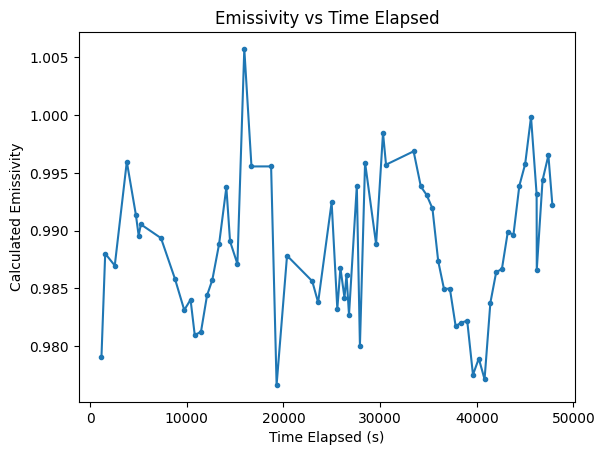

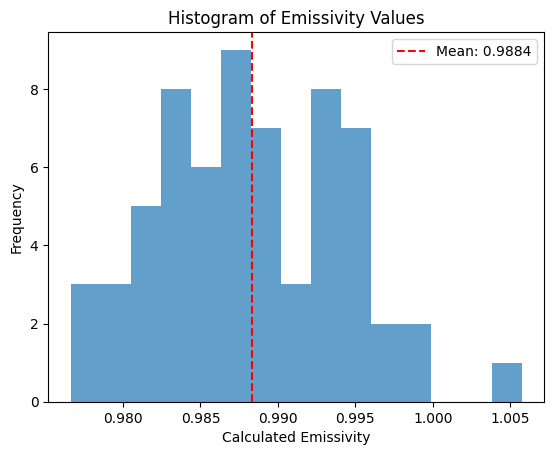

In [5]:
# Plot emissivity vs image time
# Create new time series plot
emissivity_fig, emissivity_ax = plt.subplots()

# extract emissivity values from root_scalar results
emissivity_values = [result.root for result in emissivity_list if result is not None]
emissivity_ax.plot(image_times_elapsed.iloc[:len(emissivity_values)], emissivity_values, '.-')
emissivity_ax.set_xlabel('Time Elapsed (s)')
emissivity_ax.set_ylabel('Calculated Emissivity')

# Add title
emissivity_ax.set_title('Emissivity vs Time Elapsed')

# Histogram for Emissivity Values
emissivity_hist_fig, emissivity_hist_ax = plt.subplots()

# Plot histogram of emissivity values
emissivity_hist_ax.hist(emissivity_values, bins=15, alpha=0.7)
emissivity_hist_ax.set_xlabel('Calculated Emissivity')
emissivity_hist_ax.set_ylabel('Frequency')
emissivity_hist_ax.set_title('Histogram of Emissivity Values')
emissivity_hist_ax.axvline(np.mean(emissivity_values), color='r', linestyle='--', label=f'Mean: {np.mean(emissivity_values):.4f}')
emissivity_hist_ax.legend()

In [6]:
# Finally - loop through all images again, convert to temperature, and save results
for itr, image_filename in enumerate(image_files):
    # Load image
    image_num = int(os.path.splitext(image_filename)[0])  # Remove file extension and convert to int

    # Create new camera_parameters with average of emissivity values
    camera_parameters_avg = camera_parameters.copy()
    
    # OVERRIDE WITH AVERAGE EMISSIVITY=0.99 HERE
    if use_calibrated_emissivity:
        camera_parameters_avg['Emiss'] = np.mean(emissivity_values)
    else:
        camera_parameters_avg['Emiss'] = 0.99
    
    # Create new image_convert instance with updated emissivity
    image_convert_instance = FC.image_Convert(sys.argv, camera_parameters_avg, external_optics, camera_range, image_visuals, image_dir)
    image_convert_instance.set_Camera_Range()

    # Load image
    raw_image = cv2.imread(os.path.join(image_dir, "Test Data", image_filename), cv2.IMREAD_UNCHANGED)

    # Convert image to temperature
    temperature_field = image_convert_instance.counts2temp(raw_image)

    # Save full-field image as numpy array
    # Create output directory if it doesn't exist
    processed_output_dir = os.path.join(image_dir, "Test Data", "Temperature_Fields", "numpy")
    image_output_dir = os.path.join(image_dir, "Test Data", "Temperature_Fields", "rendered")
    if not os.path.exists(image_output_dir):
        os.makedirs(image_output_dir)
    if not os.path.exists(processed_output_dir):
        os.makedirs(processed_output_dir)

    np.save(os.path.join(processed_output_dir, f"temperature_field_{image_num}_e={np.round(camera_parameters_avg['Emiss'],2)}.npy"), temperature_field)
    
    # render full field image and save as png
    full_field_fig, full_field_ax = plt.subplots()
    image_render = full_field_ax.imshow(temperature_field, cmap="magma")
    
    
    # change image ticks to mm instead of pixels
    x_ticks = full_field_ax.get_xticks()
    x_tick_labels = [f"{int(tick * spatial_res)}" for tick in x_ticks]
    full_field_ax.set_xticklabels(x_tick_labels)
    full_field_ax.set_xlabel('Distance (mm)')
    y_ticks = full_field_ax.get_yticks()
    y_tick_labels = [f"{int(tick * spatial_res)}" for tick in y_ticks]
    full_field_ax.set_yticklabels(y_tick_labels)
    full_field_ax.set_ylabel('Distance (mm)')

    # set color limits to enhance contrast
    min_scale = 0.8
    image_render.set_clim(vmin=(np.max(temperature_field)-np.min(temperature_field))*min_scale+np.min(temperature_field), vmax=np.max(temperature_field))

    # add colorbar to defaultax
    cbar = plt.colorbar(image_render, ax=full_field_ax)
    cbar.set_label('Temperature (C)', rotation=270, labelpad=15)
    
    # Add title with timestamp to defaultax from image_timestamps.csv
    image_time = image_timestamps.loc[image_num, 'time']
    full_field_ax.set_title(f'Image Timestamp: {image_time}')
    
    # Tight layout
    full_field_fig.tight_layout()
    full_field_fig.savefig(os.path.join(image_output_dir, f'temperature_field_{image_num}_e={np.round(camera_parameters_avg["Emiss"],2)}.png'))
    plt.close('all')

C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\436746540.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  full_field_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\436746540.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  full_field_ax.set_yticklabels(y_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\436746540.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  full_field_ax.set_xticklabels(x_tick_labels)
C:\Users\rujin\AppData\Local\Temp\ipykernel_23456\436746540.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  full_field_ax.set_yticklabels(y_tick_labels)
C:\Users\rujin\AppData\Local\Tem